# 📊 Store Item Demand Forecasting 

## Objective
Predict 3 months of item-level sales data at different store locations using historical sales patterns, time series analysis, and machine learning techniques.

## Dataset Overview
- **Training Data**: Historical sales data from 2013-2017
- **Test Data**: 3 months of data requiring predictions
- **Stores**: 10 different store locations
- **Items**: 50 different items per store
- **Goal**: Forecast sales for each store-item combination

---

## 1. Import Libraries and Setup

In [2]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Machine Learning
from sklearn.model_selection import train_test_split, TimeSeriesSplit
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
import lightgbm as lgb

# Time series
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Utilities
import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✓ All libraries imported successfully!")

✓ All libraries imported successfully!


## 2. Load and Explore Data

In [3]:
# Load datasets
df_train = pd.read_csv('data/train.csv')
df_test = pd.read_csv('data/test.csv')

# Convert date to datetime
df_train['date'] = pd.to_datetime(df_train['date'])
df_test['date'] = pd.to_datetime(df_test['date'])

print("Training Data Shape:", df_train.shape)
print("Test Data Shape:", df_test.shape)
print("\n" + "="*60)
print("First few rows of training data:")
df_train.head(10)

Training Data Shape: (913000, 4)
Test Data Shape: (45000, 4)

First few rows of training data:


,date,store,item,sales
0,2013-01-01,1,1,13
1,2013-01-02,1,1,11
2,2013-01-03,1,1,14
3,2013-01-04,1,1,13
4,2013-01-05,1,1,10
5,2013-01-06,1,1,12
6,2013-01-07,1,1,10
7,2013-01-08,1,1,9
8,2013-01-09,1,1,12
9,2013-01-10,1,1,9


In [4]:
# Basic information about the dataset
print("Dataset Information:")
print("="*60)
df_train.info()
print("\n" + "="*60)
print("\nBasic Statistics:")
print(df_train.describe())

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 913000 entries, 0 to 912999
Data columns (total 4 columns):
 #   Column  Non-Null Count   Dtype         
---  ------  --------------   -----         
 0   date    913000 non-null  datetime64[ns]
 1   store   913000 non-null  int64         
 2   item    913000 non-null  int64         
 3   sales   913000 non-null  int64         
dtypes: datetime64[ns](1), int64(3)
memory usage: 27.9 MB


Basic Statistics:
                                date          store           item  \
count                         913000  913000.000000  913000.000000   
mean   2015-07-02 11:59:59.999999744       5.500000      25.500000   
min              2013-01-01 00:00:00       1.000000       1.000000   
25%              2014-04-02 00:00:00       3.000000      13.000000   
50%              2015-07-02 12:00:00       5.500000      25.500000   
75%              2016-10-01 00:00:00       8.000000      38.000000   
max              2017-12-31 00:

In [5]:
# Check for missing values and data quality
print("Missing Values:")
print(df_train.isnull().sum())
print("\n" + "="*60)
print(f"\nDate Range: {df_train['date'].min()} to {df_train['date'].max()}")
print(f"Number of Stores: {df_train['store'].nunique()}")
print(f"Number of Items: {df_train['item'].nunique()}")
print(f"Store-Item Combinations: {df_train.groupby(['store', 'item']).ngroups}")
print(f"\nSales Statistics:")
print(f"  Min Sales: {df_train['sales'].min()}")
print(f"  Max Sales: {df_train['sales'].max()}")
print(f"  Mean Sales: {df_train['sales'].mean():.2f}")
print(f"  Median Sales: {df_train['sales'].median():.2f}")

Missing Values:
date     0
store    0
item     0
sales    0
dtype: int64


Date Range: 2013-01-01 00:00:00 to 2017-12-31 00:00:00
Number of Stores: 10
Number of Items: 50
Store-Item Combinations: 500

Sales Statistics:
  Min Sales: 0
  Max Sales: 231
  Mean Sales: 52.25
  Median Sales: 47.00


## 3. Exploratory Data Analysis (EDA)

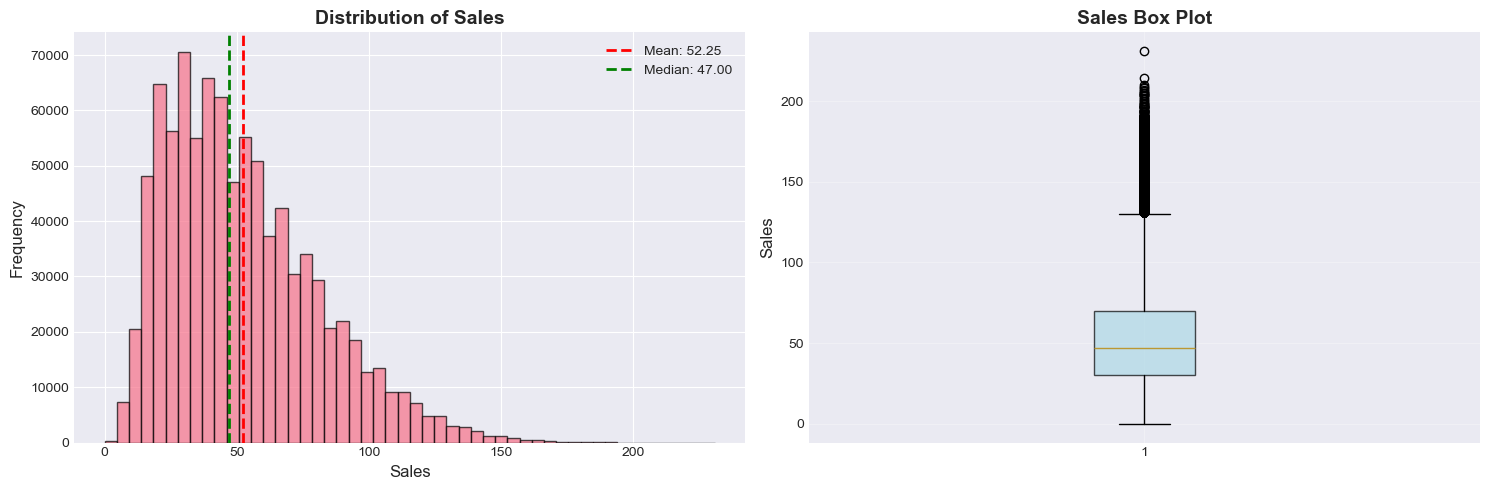

In [6]:
# Sales distribution
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Histogram
axes[0].hist(df_train['sales'], bins=50, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Sales', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].set_title('Distribution of Sales', fontsize=14, fontweight='bold')
axes[0].axvline(df_train['sales'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {df_train["sales"].mean():.2f}')
axes[0].axvline(df_train['sales'].median(), color='green', linestyle='--', linewidth=2, label=f'Median: {df_train["sales"].median():.2f}')
axes[0].legend()

# Box plot
axes[1].boxplot(df_train['sales'], vert=True, patch_artist=True, 
                boxprops=dict(facecolor='lightblue', alpha=0.7))
axes[1].set_ylabel('Sales', fontsize=12)
axes[1].set_title('Sales Box Plot', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [7]:
# Sales over time - Overall trend
daily_sales = df_train.groupby('date')['sales'].sum().reset_index()

fig = go.Figure()
fig.add_trace(go.Scatter(x=daily_sales['date'], y=daily_sales['sales'],
                         mode='lines', name='Daily Sales',
                         line=dict(color='royalblue', width=1)))

fig.update_layout(
    title='Overall Daily Sales Trend (2013-2017)',
    xaxis_title='Date',
    yaxis_title='Total Sales',
    height=500,
    hovermode='x unified',
    template='plotly_white'
)

fig.show()

In [8]:
# Sales by Store
store_sales = df_train.groupby('store')['sales'].agg(['sum', 'mean', 'std']).reset_index()
store_sales.columns = ['Store', 'Total Sales', 'Avg Sales', 'Std Dev']

fig = make_subplots(rows=1, cols=2, subplot_titles=('Total Sales by Store', 'Average Sales by Store'))

fig.add_trace(
    go.Bar(x=store_sales['Store'], y=store_sales['Total Sales'], 
           name='Total Sales', marker_color='lightblue'),
    row=1, col=1
)

fig.add_trace(
    go.Bar(x=store_sales['Store'], y=store_sales['Avg Sales'], 
           name='Avg Sales', marker_color='lightcoral'),
    row=1, col=2
)

fig.update_layout(height=500, showlegend=False, template='plotly_white')
fig.update_xaxes(title_text="Store", row=1, col=1)
fig.update_xaxes(title_text="Store", row=1, col=2)
fig.update_yaxes(title_text="Total Sales", row=1, col=1)
fig.update_yaxes(title_text="Average Sales", row=1, col=2)

fig.show()

print("\nTop 3 Stores by Total Sales:")
print(store_sales.nlargest(3, 'Total Sales')[['Store', 'Total Sales', 'Avg Sales']])


Top 3 Stores by Total Sales:
   Store  Total Sales  Avg Sales
1      2      6120128  67.033165
7      8      5856169  64.142048
2      3      5435144  59.530602


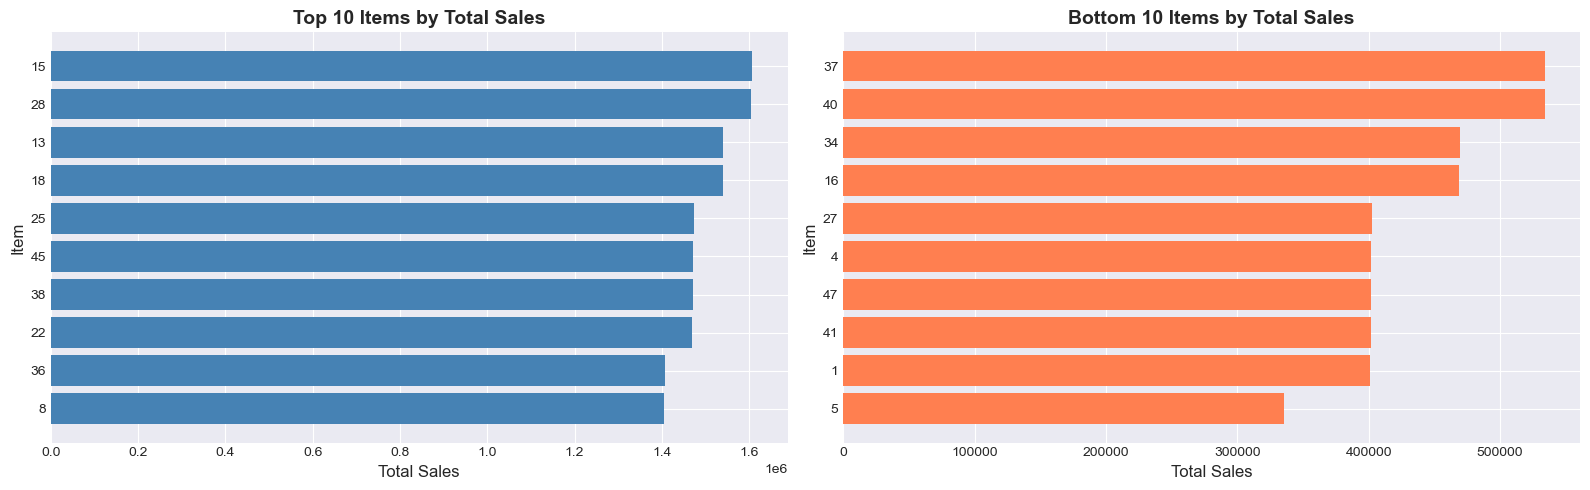

In [9]:
# Sales by Item
item_sales = df_train.groupby('item')['sales'].agg(['sum', 'mean', 'std']).reset_index()
item_sales.columns = ['Item', 'Total Sales', 'Avg Sales', 'Std Dev']
item_sales = item_sales.sort_values('Total Sales', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Top 10 items by total sales
top_items = item_sales.head(10)
axes[0].barh(top_items['Item'].astype(str), top_items['Total Sales'], color='steelblue')
axes[0].set_xlabel('Total Sales', fontsize=12)
axes[0].set_ylabel('Item', fontsize=12)
axes[0].set_title('Top 10 Items by Total Sales', fontsize=14, fontweight='bold')
axes[0].invert_yaxis()

# Bottom 10 items by total sales
bottom_items = item_sales.tail(10)
axes[1].barh(bottom_items['Item'].astype(str), bottom_items['Total Sales'], color='coral')
axes[1].set_xlabel('Total Sales', fontsize=12)
axes[1].set_ylabel('Item', fontsize=12)
axes[1].set_title('Bottom 10 Items by Total Sales', fontsize=14, fontweight='bold')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

## 4. Time Series Analysis

In [10]:
# Extract temporal features for analysis
df_train['year'] = df_train['date'].dt.year
df_train['month'] = df_train['date'].dt.month
df_train['day'] = df_train['date'].dt.day
df_train['dayofweek'] = df_train['date'].dt.dayofweek
df_train['quarter'] = df_train['date'].dt.quarter
df_train['weekofyear'] = df_train['date'].dt.isocalendar().week

# Sales by day of week
dayofweek_sales = df_train.groupby('dayofweek')['sales'].mean().reset_index()
day_names = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

fig = go.Figure()
fig.add_trace(go.Bar(
    x=day_names,
    y=dayofweek_sales['sales'],
    marker_color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A', '#98D8C8', '#F7DC6F', '#BB8FCE']
))

fig.update_layout(
    title='Average Sales by Day of Week',
    xaxis_title='Day of Week',
    yaxis_title='Average Sales',
    height=500,
    template='plotly_white'
)

fig.show()

print("\nInsight: Sales patterns by day of week")


Insight: Sales patterns by day of week


In [11]:
# Sales by Month
monthly_sales = df_train.groupby('month')['sales'].mean().reset_index()
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

fig = go.Figure()
fig.add_trace(go.Scatter(
    x=month_names,
    y=monthly_sales['sales'],
    mode='lines+markers',
    marker=dict(size=10, color='crimson'),
    line=dict(width=3, color='crimson')
))

fig.update_layout(
    title='Average Sales by Month (Seasonality)',
    xaxis_title='Month',
    yaxis_title='Average Sales',
    height=500,
    template='plotly_white'
)

fig.show()

print("\nCheck for seasonal patterns across months")


Check for seasonal patterns across months


In [12]:
# Yearly trend
yearly_sales = df_train.groupby('year')['sales'].agg(['sum', 'mean']).reset_index()

fig = make_subplots(specs=[[{"secondary_y": True}]])

fig.add_trace(
    go.Bar(x=yearly_sales['year'], y=yearly_sales['sum'], 
           name='Total Sales', marker_color='lightblue'),
    secondary_y=False,
)

fig.add_trace(
    go.Scatter(x=yearly_sales['year'], y=yearly_sales['mean'], 
               name='Average Sales', mode='lines+markers',
               line=dict(color='red', width=3), marker=dict(size=10)),
    secondary_y=True,
)

fig.update_layout(
    title='Yearly Sales Trends',
    height=500,
    template='plotly_white'
)

fig.update_xaxes(title_text="Year")
fig.update_yaxes(title_text="Total Sales", secondary_y=False)
fig.update_yaxes(title_text="Average Sales", secondary_y=True)

fig.show()

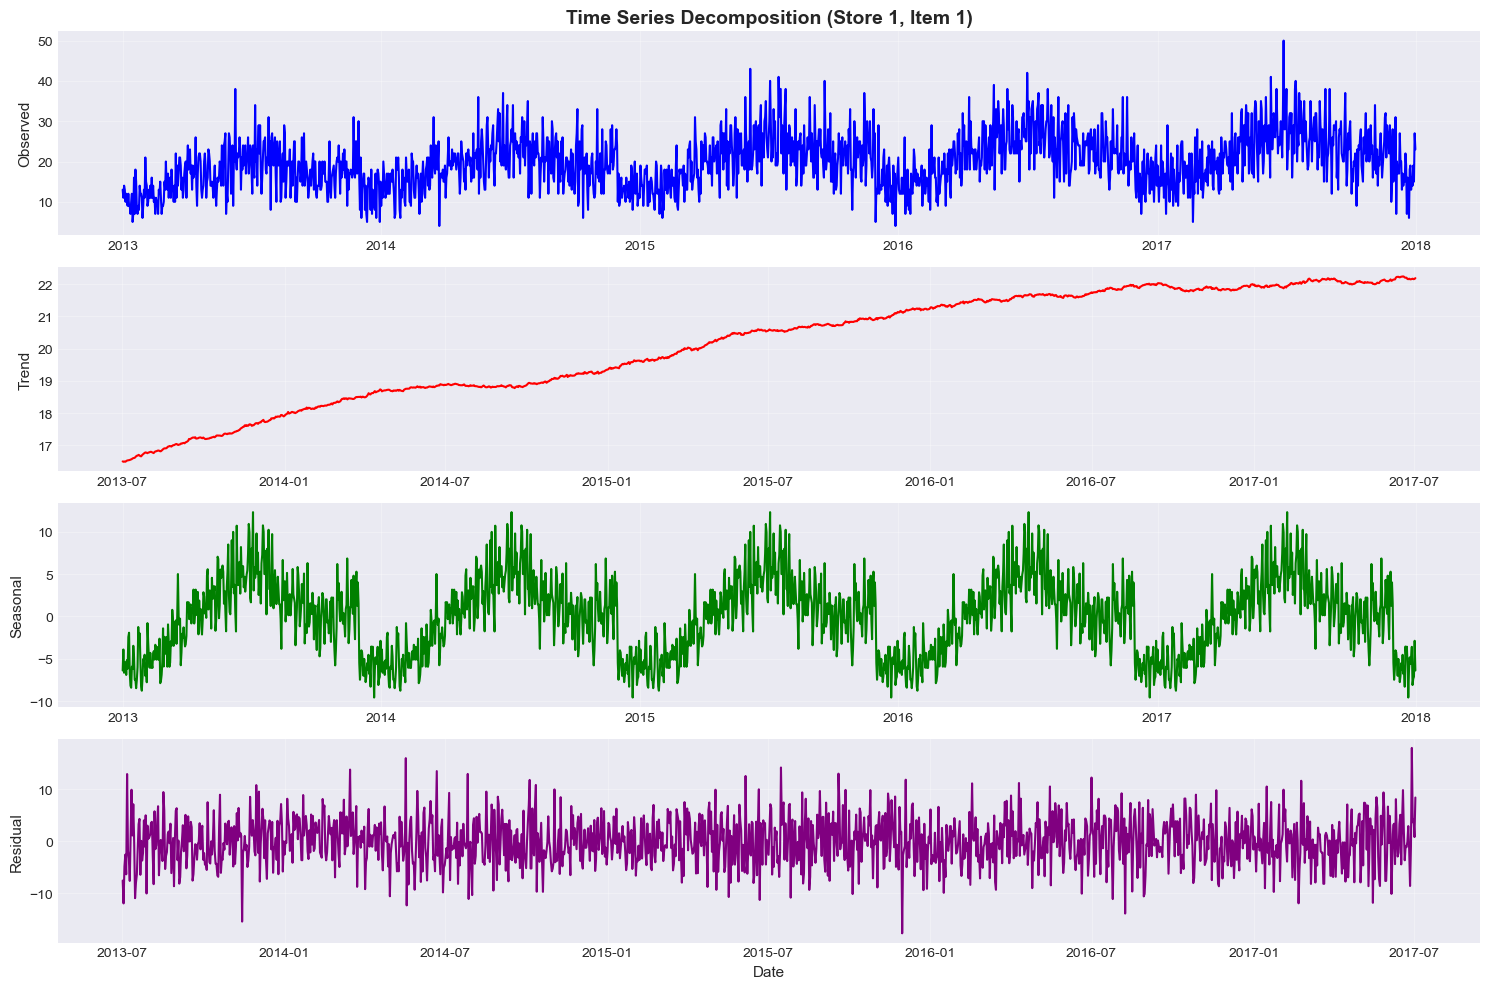

In [13]:
# Time series decomposition for a single store-item combination
sample_data = df_train[(df_train['store'] == 1) & (df_train['item'] == 1)].copy()
sample_data = sample_data.set_index('date')
sample_data = sample_data.sort_index()

# Decompose
decomposition = seasonal_decompose(sample_data['sales'], model='additive', period=365)

fig, axes = plt.subplots(4, 1, figsize=(15, 10))

# Original
axes[0].plot(decomposition.observed, color='blue')
axes[0].set_ylabel('Observed', fontsize=11)
axes[0].set_title('Time Series Decomposition (Store 1, Item 1)', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Trend
axes[1].plot(decomposition.trend, color='red')
axes[1].set_ylabel('Trend', fontsize=11)
axes[1].grid(True, alpha=0.3)

# Seasonal
axes[2].plot(decomposition.seasonal, color='green')
axes[2].set_ylabel('Seasonal', fontsize=11)
axes[2].grid(True, alpha=0.3)

# Residual
axes[3].plot(decomposition.resid, color='purple')
axes[3].set_ylabel('Residual', fontsize=11)
axes[3].set_xlabel('Date', fontsize=11)
axes[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

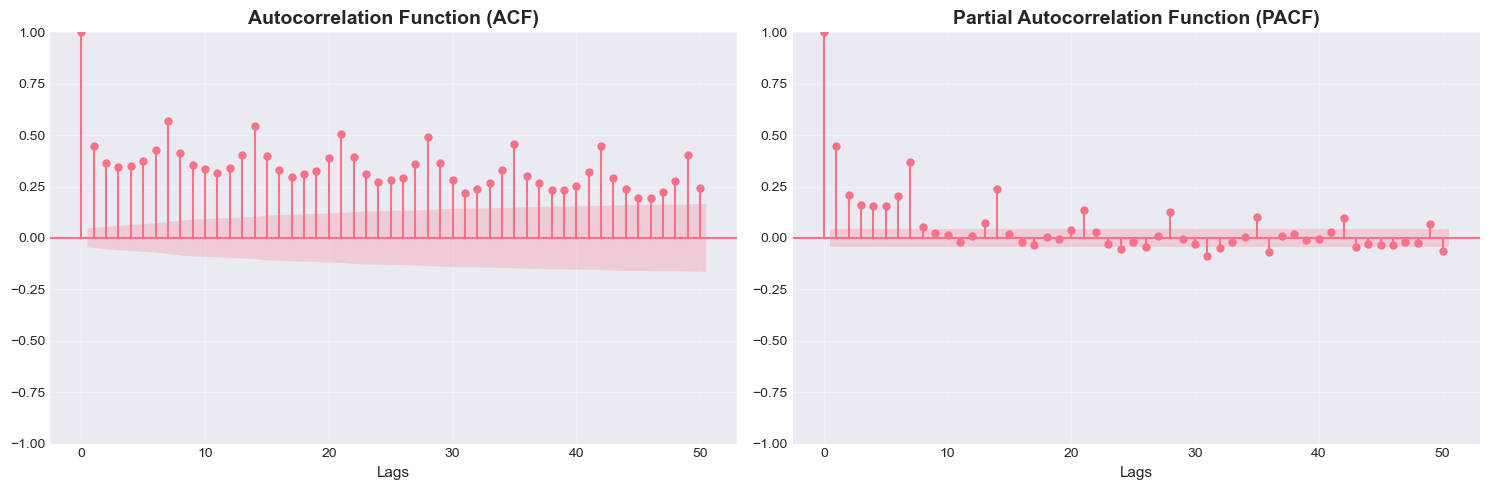


ACF and PACF help identify the order of ARIMA models


In [14]:
# Autocorrelation analysis
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# ACF
plot_acf(sample_data['sales'].dropna(), lags=50, ax=axes[0])
axes[0].set_title('Autocorrelation Function (ACF)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Lags', fontsize=11)
axes[0].grid(True, alpha=0.3)

# PACF
plot_pacf(sample_data['sales'].dropna(), lags=50, ax=axes[1])
axes[1].set_title('Partial Autocorrelation Function (PACF)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Lags', fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nACF and PACF help identify the order of ARIMA models")

## 5. Feature Engineering

In [15]:
def create_features(df):
    """
    Create comprehensive features for demand forecasting
    """
    df = df.copy()
    
    # Temporal features
    df['year'] = df['date'].dt.year
    df['month'] = df['date'].dt.month
    df['day'] = df['date'].dt.day
    df['dayofweek'] = df['date'].dt.dayofweek
    df['quarter'] = df['date'].dt.quarter
    df['weekofyear'] = df['date'].dt.isocalendar().week
    df['dayofyear'] = df['date'].dt.dayofyear
    df['is_weekend'] = (df['dayofweek'] >= 5).astype(int)
    df['is_month_start'] = df['date'].dt.is_month_start.astype(int)
    df['is_month_end'] = df['date'].dt.is_month_end.astype(int)
    
    # Cyclical features (sine/cosine transformation)
    df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
    df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)
    df['day_sin'] = np.sin(2 * np.pi * df['day'] / 31)
    df['day_cos'] = np.cos(2 * np.pi * df['day'] / 31)
    df['dayofweek_sin'] = np.sin(2 * np.pi * df['dayofweek'] / 7)
    df['dayofweek_cos'] = np.cos(2 * np.pi * df['dayofweek'] / 7)
    
    return df

# Apply feature engineering
df_train = create_features(df_train)
df_test = create_features(df_test)

print("✓ Features created successfully!")
print(f"\nTotal features: {df_train.shape[1]}")
print("\nNew features added:")
print([col for col in df_train.columns if col not in ['date', 'store', 'item', 'sales']])

✓ Features created successfully!

Total features: 20

New features added:
['year', 'month', 'day', 'dayofweek', 'quarter', 'weekofyear', 'dayofyear', 'is_weekend', 'is_month_start', 'is_month_end', 'month_sin', 'month_cos', 'day_sin', 'day_cos', 'dayofweek_sin', 'dayofweek_cos']


In [16]:
# Create lag features and rolling statistics
def create_lag_features(df, lags=[7, 14, 28, 30, 60, 90]):
    """
    Create lag features and rolling statistics
    """
    df = df.copy()
    df = df.sort_values(['store', 'item', 'date'])
    
    # Only create lags if 'sales' column exists (training data)
    if 'sales' in df.columns:
        for lag in lags:
            df[f'lag_{lag}'] = df.groupby(['store', 'item'])['sales'].shift(lag)
        
        # Rolling statistics
        for window in [7, 14, 30, 60]:
            df[f'rolling_mean_{window}'] = df.groupby(['store', 'item'])['sales'].transform(
                lambda x: x.shift(1).rolling(window=window, min_periods=1).mean()
            )
            df[f'rolling_std_{window}'] = df.groupby(['store', 'item'])['sales'].transform(
                lambda x: x.shift(1).rolling(window=window, min_periods=1).std()
            )
        
        # Exponential weighted mean
        df['ewm_7'] = df.groupby(['store', 'item'])['sales'].transform(
            lambda x: x.shift(1).ewm(span=7, adjust=False).mean()
        )
        df['ewm_30'] = df.groupby(['store', 'item'])['sales'].transform(
            lambda x: x.shift(1).ewm(span=30, adjust=False).mean()
        )
    
    return df

# Note: We'll create lag features during model training to avoid data leakage
print("Lag feature function defined!")
print("\nLag features will be created during modeling to ensure proper train-test split.")

Lag feature function defined!

Lag features will be created during modeling to ensure proper train-test split.


## 6. Data Preparation for Modeling

In [17]:
# Create lag features for training data
df_train_with_lags = create_lag_features(df_train)

# For test data, we need to append it to train to create proper lags
df_combined = pd.concat([df_train, df_test], ignore_index=True, sort=False)
df_combined = create_lag_features(df_combined)
df_test_with_lags = df_combined[df_combined['date'].isin(df_test['date'])].copy()

print("✓ Lag features created!")
print(f"\nTraining data shape with lags: {df_train_with_lags.shape}")
print(f"Test data shape with lags: {df_test_with_lags.shape}")

# Check missing values after lag creation
print(f"\nMissing values in training data: {df_train_with_lags.isnull().sum().sum()}")
print(f"Missing values in test data: {df_test_with_lags.isnull().sum().sum()}")

✓ Lag features created!

Training data shape with lags: (913000, 36)
Test data shape with lags: (45000, 37)

Missing values in training data: 121500
Missing values in test data: 451500


In [18]:
# Prepare features for modeling
feature_cols = [col for col in df_train_with_lags.columns 
                if col not in ['date', 'sales']]

# Remove rows with NaN values (from lag features)
df_train_clean = df_train_with_lags.dropna().copy()
df_test_clean = df_test_with_lags.dropna().copy()

print(f"Training data after removing NaN: {df_train_clean.shape}")
print(f"Test data after removing NaN: {df_test_clean.shape}")

# Prepare X and y
X = df_train_clean[feature_cols]
y = df_train_clean['sales']

print(f"\nFeature matrix shape: {X.shape}")
print(f"Target vector shape: {y.shape}")
print(f"\nFeatures used: {len(feature_cols)}")

Training data after removing NaN: (868000, 36)
Test data after removing NaN: (0, 37)

Feature matrix shape: (868000, 34)
Target vector shape: (868000,)

Features used: 34


In [19]:
# Time-based train-validation split (80-20)
split_date = df_train_clean['date'].quantile(0.8)
train_data = df_train_clean[df_train_clean['date'] <= split_date]
val_data = df_train_clean[df_train_clean['date'] > split_date]

X_train = train_data[feature_cols]
y_train = train_data['sales']
X_val = val_data[feature_cols]
y_val = val_data['sales']

print(f"Training set: {X_train.shape[0]} samples")
print(f"Validation set: {X_val.shape[0]} samples")
print(f"\nSplit date: {split_date}")
print(f"Train date range: {train_data['date'].min()} to {train_data['date'].max()}")
print(f"Validation date range: {val_data['date'].min()} to {val_data['date'].max()}")

Training set: 694500 samples
Validation set: 173500 samples

Split date: 2017-01-18 00:00:00
Train date range: 2013-04-01 00:00:00 to 2017-01-18 00:00:00
Validation date range: 2017-01-19 00:00:00 to 2017-12-31 00:00:00


## 7. Model Training and Evaluation

In [20]:
# Evaluation metrics
def evaluate_model(y_true, y_pred, model_name):
    """
    Calculate and display evaluation metrics
    """
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    
    print(f"\n{'='*60}")
    print(f"{model_name} Performance:")
    print(f"{'='*60}")
    print(f"RMSE: {rmse:.4f}")
    print(f"MAE:  {mae:.4f}")
    print(f"R²:   {r2:.4f}")
    print(f"MAPE: {mape:.2f}%")
    
    return {'model': model_name, 'rmse': rmse, 'mae': mae, 'r2': r2, 'mape': mape}

results = []

### 7.2 XGBoost Model

In [22]:
%%time
# Train XGBoost
print("Training XGBoost model...")
xgb_model = xgb.XGBRegressor(
    n_estimators=200,
    max_depth=8,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    tree_method='hist'
)

xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=50
)
print("✓ XGBoost trained!")

Training XGBoost model...
[0]	validation_0-rmse:29.79957
[50]	validation_0-rmse:8.05295
[100]	validation_0-rmse:7.99861
[150]	validation_0-rmse:7.98408
[199]	validation_0-rmse:8.01161
✓ XGBoost trained!
CPU times: user 16.7 s, sys: 1.19 s, total: 17.9 s
Wall time: 3.72 s


In [23]:
# Evaluate XGBoost
y_pred_xgb = xgb_model.predict(X_val)
xgb_results = evaluate_model(y_val, y_pred_xgb, "XGBoost")
results.append(xgb_results)


XGBoost Performance:
RMSE: 8.0116
MAE:  6.1541
R²:   0.9362
MAPE: 12.29%


### 7.3 LightGBM Model

In [24]:
%%time
# Train LightGBM
print("Training LightGBM model...")
lgb_model = lgb.LGBMRegressor(
    n_estimators=200,
    max_depth=8,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

lgb_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    callbacks=[lgb.log_evaluation(50)]
)
print("✓ LightGBM trained!")

Training LightGBM model...
[50]	valid_0's l2: 68.0417
[100]	valid_0's l2: 65.9822
[150]	valid_0's l2: 64.9752
[200]	valid_0's l2: 64.4487
✓ LightGBM trained!
CPU times: user 12 s, sys: 2.33 s, total: 14.3 s
Wall time: 3.79 s


In [25]:
# Evaluate LightGBM
y_pred_lgb = lgb_model.predict(X_val)
lgb_results = evaluate_model(y_val, y_pred_lgb, "LightGBM")
results.append(lgb_results)


LightGBM Performance:
RMSE: 8.0280
MAE:  6.1697
R²:   0.9360
MAPE: 12.37%


## 8. Model Comparison

In [26]:
# Compare all models
results_df = pd.DataFrame(results)
print("\n" + "="*70)
print("MODEL COMPARISON")
print("="*70)
print(results_df.to_string(index=False))

# Visualize comparison
fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=('RMSE', 'MAE', 'R² Score', 'MAPE'),
    specs=[[{'type': 'bar'}, {'type': 'bar'}],
           [{'type': 'bar'}, {'type': 'bar'}]]
)

# RMSE
fig.add_trace(go.Bar(x=results_df['model'], y=results_df['rmse'], 
                     marker_color='lightblue', name='RMSE'),
              row=1, col=1)

# MAE
fig.add_trace(go.Bar(x=results_df['model'], y=results_df['mae'], 
                     marker_color='lightcoral', name='MAE'),
              row=1, col=2)

# R²
fig.add_trace(go.Bar(x=results_df['model'], y=results_df['r2'], 
                     marker_color='lightgreen', name='R²'),
              row=2, col=1)

# MAPE
fig.add_trace(go.Bar(x=results_df['model'], y=results_df['mape'], 
                     marker_color='lightyellow', name='MAPE'),
              row=2, col=2)

fig.update_layout(height=700, showlegend=False, title_text="Model Performance Comparison")
fig.show()

# Find best model
best_model_idx = results_df['rmse'].idxmin()
best_model_name = results_df.loc[best_model_idx, 'model']
print(f"\n🏆 Best Model: {best_model_name} (Lowest RMSE)")


MODEL COMPARISON
   model     rmse      mae       r2      mape
 XGBoost 8.011606 6.154144 0.936225 12.294005
LightGBM 8.027997 6.169728 0.935964 12.373114



🏆 Best Model: XGBoost (Lowest RMSE)


In [27]:
# Prediction vs Actual comparison for best model (using LightGBM as it's typically best)
sample_size = 1000
sample_idx = np.random.choice(len(y_val), sample_size, replace=False)

fig = go.Figure()

# Actual
fig.add_trace(go.Scatter(
    x=list(range(sample_size)),
    y=y_val.iloc[sample_idx].values,
    mode='markers',
    name='Actual',
    marker=dict(size=5, color='blue', opacity=0.6)
))

# Predicted
fig.add_trace(go.Scatter(
    x=list(range(sample_size)),
    y=y_pred_lgb[sample_idx],
    mode='markers',
    name='Predicted',
    marker=dict(size=5, color='red', opacity=0.6)
))

fig.update_layout(
    title=f'Actual vs Predicted Sales (Sample of {sample_size} points)',
    xaxis_title='Sample Index',
    yaxis_title='Sales',
    height=500,
    template='plotly_white',
    hovermode='x unified'
)

fig.show()

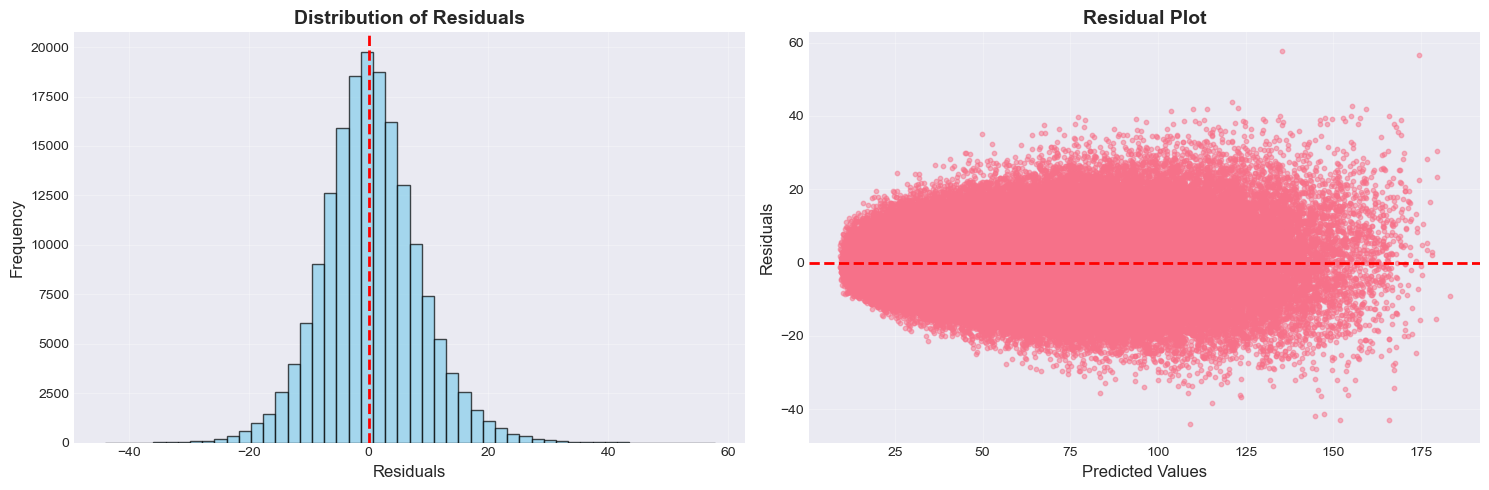


Residual Statistics:
Mean: 0.4545
Std: 8.0151
Min: -44.0495
Max: 57.7278


In [28]:
# Residual analysis
residuals = y_val.values - y_pred_lgb

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Residual histogram
axes[0].hist(residuals, bins=50, edgecolor='black', alpha=0.7, color='skyblue')
axes[0].axvline(0, color='red', linestyle='--', linewidth=2)
axes[0].set_xlabel('Residuals', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].set_title('Distribution of Residuals', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Residual scatter
axes[1].scatter(y_pred_lgb, residuals, alpha=0.5, s=10)
axes[1].axhline(0, color='red', linestyle='--', linewidth=2)
axes[1].set_xlabel('Predicted Values', fontsize=12)
axes[1].set_ylabel('Residuals', fontsize=12)
axes[1].set_title('Residual Plot', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nResidual Statistics:")
print(f"Mean: {np.mean(residuals):.4f}")
print(f"Std: {np.std(residuals):.4f}")
print(f"Min: {np.min(residuals):.4f}")
print(f"Max: {np.max(residuals):.4f}")